In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: False
Device: CPU only


In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/gpr_fwi_diffusion'
os.chdir(PROJECT_DIR)
print("Working directory:", os.getcwd())
print("Files in Drive:", os.listdir(PROJECT_DIR))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/gpr_fwi_diffusion
Files in Drive: ['groundtruth.png', 'observed_data.png', 'obs_data.npy', 'trace_cols.npy', 'gpr_synthetic_dataset.pt', 'loss_history.pt', 'diffusion_unet_weights.pt', 'loss_curves.npy', 'all_metrics.npy', 'inversion_results.npy', 'obs_data_hard.npy', 'trace_cols_hard.npy', 'inversion_results_hard.npy', 'all_metrics_hard.npy', 'figure5_comparison_preview.png', 'obs_data_v2.npy', 'trace_cols_v2.npy', 'all_metrics_v2.npy', 'inversion_results_v2.npy', 'obs_data_v3.npy', 'trace_cols_v3.npy', 'eps_true.npy', 'sig_true.npy', 'figure5_comparison_v3.png', 'inversion_results_v3.npy', 'figure5_comparison_400iter.png', 'all_metrics_v3.npy', 'figure5_final.png']


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# ---- Normalization bounds ----
EPS_MIN, EPS_MAX = 2.0, 25.0
SIG_MIN, SIG_MAX = 0.0001, 0.05

def normalize(x, lo, hi):
    return 2 * (np.clip(x, lo, hi) - lo) / (hi - lo) - 1

def denormalize(x, lo, hi):
    return (x + 1) / 2 * (hi - lo) + lo

# ---- U-Net ----
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_ch=2, base_ch=64, time_emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim), nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim))
        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)
        self.down1 = ResidualBlock(base_ch, base_ch, time_emb_dim)
        self.pool1 = nn.Conv2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.down2 = ResidualBlock(base_ch, base_ch*2, time_emb_dim)
        self.pool2 = nn.Conv2d(base_ch*2, base_ch*2, 4, stride=2, padding=1)
        self.down3 = ResidualBlock(base_ch*2, base_ch*4, time_emb_dim)
        self.pool3 = nn.Conv2d(base_ch*4, base_ch*4, 4, stride=2, padding=1)
        self.bottleneck = ResidualBlock(base_ch*4, base_ch*4, time_emb_dim)
        self.up3 = nn.ConvTranspose2d(base_ch*4, base_ch*4, 4, stride=2, padding=1)
        self.dec3 = ResidualBlock(base_ch*8, base_ch*2, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(base_ch*2, base_ch*2, 4, stride=2, padding=1)
        self.dec2 = ResidualBlock(base_ch*4, base_ch, time_emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.dec1 = ResidualBlock(base_ch*2, base_ch, time_emb_dim)
        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, base_ch), nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, 3, padding=1))
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x0 = self.in_conv(x)
        d1 = self.down1(x0, t_emb)
        d2 = self.down2(self.pool1(d1), t_emb)
        d3 = self.down3(self.pool2(d2), t_emb)
        b  = self.bottleneck(self.pool3(d3), t_emb)
        u3 = self.dec3(torch.cat([self.up3(b),  d3], dim=1), t_emb)
        u2 = self.dec2(torch.cat([self.up2(u3), d2], dim=1), t_emb)
        u1 = self.dec1(torch.cat([self.up1(u2), d1], dim=1), t_emb)
        return self.out_conv(u1)

class DiffusionSchedule:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cuda'):
        self.timesteps = timesteps
        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac   = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_omac = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x0 + sqrt_omac * noise

# ---- Load trained model ----
model    = SimpleUNet().to(device)
schedule = DiffusionSchedule(timesteps=1000, device=device)
model.load_state_dict(torch.load('diffusion_unet_weights.pt', map_location=device))
model.eval()
print("Diffusion model loaded.")

# ---- Forward model ----
def forward_model(eps, sig, n_traces=32, noise_level=0.0):
    H, W = eps.shape
    t = np.linspace(-1, 1, 21)
    f0 = 0.3
    wavelet    = (1 - 2*(np.pi*f0*t)**2) * np.exp(-(np.pi*f0*t)**2)
    trace_cols = np.linspace(0, W-1, n_traces, dtype=int)
    data       = np.zeros((n_traces, H), dtype=np.float32)
    for i, col in enumerate(trace_cols):
        impedance   = 1.0 / np.sqrt(eps[:, col])
        refl        = np.diff(impedance, prepend=impedance[0])
        attenuation = np.exp(-np.cumsum(sig[:, col]) * 2.0)
        data[i]     = np.convolve(refl * attenuation, wavelet, mode='same')
    if noise_level > 0:
        data += noise_level * np.std(data) * np.random.randn(*data.shape)
    return data.astype(np.float32), trace_cols

def compute_gradient(eps, sig, obs_data, trace_cols):
    H, W      = eps.shape
    t         = np.linspace(-1, 1, 21)
    f0        = 0.3
    wavelet   = (1 - 2*(np.pi*f0*t)**2) * np.exp(-(np.pi*f0*t)**2)
    pred_data = forward_model(eps, sig, n_traces=len(trace_cols))[0]
    residual  = pred_data - obs_data
    misfit    = 0.5 * np.sum(residual**2)
    grad_eps  = np.zeros_like(eps)
    grad_sig  = np.zeros_like(sig)
    for i, col in enumerate(trace_cols):
        adj         = np.convolve(residual[i], wavelet[::-1], mode='same')
        attenuation = np.exp(-np.cumsum(sig[:, col]) * 2.0)
        d_imp_d_eps = -0.5 / (eps[:, col]**1.5)
        for d in range(H):
            grad_eps[d, col] += adj[d] * attenuation[d] * d_imp_d_eps[d]
        for d in range(H):
            grad_sig[d, col] += -2.0 * adj[d] * attenuation[d] * \
                                  np.sum(adj[:d+1])
    return grad_eps, grad_sig, misfit

@torch.no_grad()
def diffusion_project_gentle(eps_arr, sig_arr, t_start=50):
    eps_n = normalize(eps_arr, EPS_MIN, EPS_MAX)
    sig_n = normalize(sig_arr, SIG_MIN, SIG_MAX)
    x0    = torch.from_numpy(
        np.stack([eps_n, sig_n], axis=0)[None]).float().to(device)
    t_tensor = torch.tensor([t_start], device=device)
    x        = schedule.q_sample(x0, t_tensor, torch.randn_like(x0))
    for t_cur in reversed(range(0, t_start)):
        t_cur_tensor = torch.tensor([t_cur], device=device)
        beta_t    = schedule.betas[t_cur]
        alpha_t   = schedule.alphas[t_cur]
        alpha_bar = schedule.alphas_cumprod[t_cur]
        pred_noise = model(x, t_cur_tensor)
        if t_cur > 0:
            coef = beta_t / torch.sqrt(1 - alpha_bar)
            x    = (1 / torch.sqrt(alpha_t)) * (x - coef * pred_noise)
        else:
            x = (x - torch.sqrt(1 - alpha_bar) * pred_noise) / \
                 torch.sqrt(alpha_bar)
            x = torch.clamp(x, -1, 1)
    x_d     = x.squeeze(0).cpu().numpy()
    eps_den = np.clip(denormalize(x_d[0], EPS_MIN, EPS_MAX), EPS_MIN, EPS_MAX)
    sig_den = np.clip(denormalize(x_d[1], SIG_MIN, SIG_MAX), SIG_MIN, SIG_MAX)
    return eps_den, sig_den

from skimage.metrics import structural_similarity as skssim
def compute_metrics(recon, true):
    rmse     = np.sqrt(np.mean((recon - true)**2))
    ssim_val = skssim(true, recon, data_range=true.max() - true.min())
    return rmse, ssim_val

print("All definitions ready.")

Device: cuda
Diffusion model loaded.
All definitions ready.


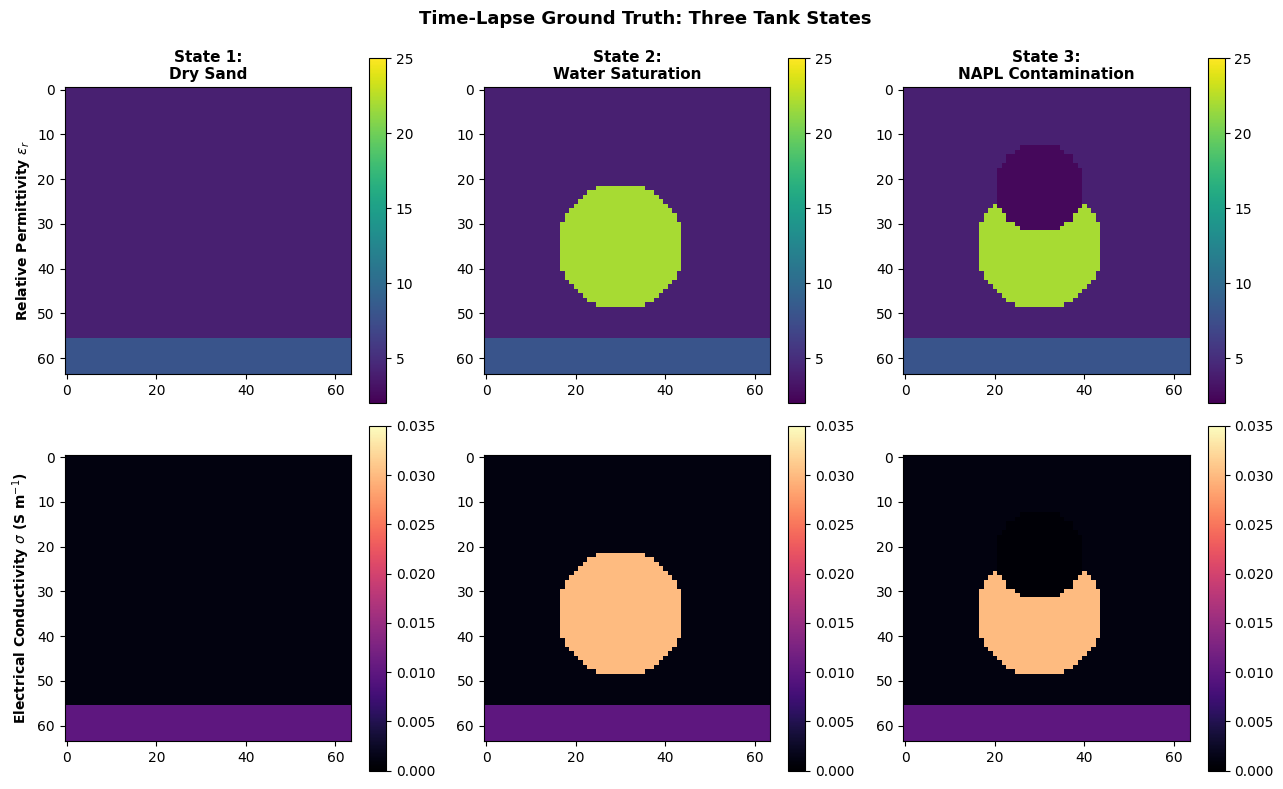

Three states saved to Drive.
Dry:   eps=4.0-8.0, sig=0.0010-0.0100
Water: eps=4.0-22.0, sig=0.0010-0.0300
NAPL:  eps=2.5-22.0, sig=0.0004-0.0300


In [4]:
from skimage.draw import disk

np.random.seed(42)
H, W = 64, 64

# ---- Shared background (all three states) ----
def make_background():
    eps = np.full((H, W), 4.0, dtype=np.float32)
    sig = np.full((H, W), 0.001, dtype=np.float32)
    eps[56:, :] = 8.0   # concrete base
    sig[56:, :] = 0.01
    return eps, sig

# ---- State 1: Dry sand (baseline, no anomaly) ----
eps_dry, sig_dry = make_background()

# ---- State 2: Water saturation ----
# Water blob: large irregular region, middle-lower sand layer
eps_water, sig_water = make_background()
rr, cc = disk((35, 30), 14, shape=(H, W))
rr = rr[rr < 56]   # keep within sand layer
cc = cc[rr < 56] if len(cc) > len(rr[rr<56]) else cc[:len(rr[rr<56])]
rr_w, cc_w = rr, cc
eps_water[rr_w, cc_w] = 22.0
sig_water[rr_w, cc_w] = 0.03

# ---- State 3: NAPL contamination (sits above water) ----
# NAPL lens: sits above the water zone (lighter, buoyant)
# Water zone persists but slightly shrunk as NAPL displaces some water
eps_napl, sig_napl = make_background()
# Water zone (slightly reduced)
eps_napl[rr_w, cc_w] = 22.0
sig_napl[rr_w, cc_w] = 0.03
# NAPL lens on top
rr_n, cc_n = disk((22, 30), 10, shape=(H, W))
rr_n = rr_n[rr_n < 56]
cc_n = cc_n[:len(rr_n)]
eps_napl[rr_n, cc_n] = 2.5   # NAPL: low eps_r
sig_napl[rr_n, cc_n] = 0.0004 # NAPL: very low sigma

# ---- Visualize all three states ----
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
states     = ['State 1:\nDry Sand', 'State 2:\nWater Saturation',
               'State 3:\nNAPL Contamination']
eps_models = [eps_dry, eps_water, eps_napl]
sig_models = [sig_dry, sig_water, sig_napl]

for j in range(3):
    im0 = axes[0, j].imshow(eps_models[j], cmap='viridis', vmin=2, vmax=25)
    axes[0, j].set_title(states[j], fontsize=11, fontweight='bold')
    if j == 0:
        axes[0, j].set_ylabel(r'Relative Permittivity $\varepsilon_r$',
                               fontsize=10, fontweight='bold')
    plt.colorbar(im0, ax=axes[0, j])

    im1 = axes[1, j].imshow(sig_models[j], cmap='magma', vmin=0, vmax=0.035)
    if j == 0:
        axes[1, j].set_ylabel(r'Electrical Conductivity $\sigma$ (S m$^{-1}$)',
                               fontsize=10, fontweight='bold')
    plt.colorbar(im1, ax=axes[1, j])

plt.suptitle('Time-Lapse Ground Truth: Three Tank States',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Save to Drive
np.save('eps_dry.npy',   eps_dry);   np.save('sig_dry.npy',   sig_dry)
np.save('eps_water.npy', eps_water); np.save('sig_water.npy', sig_water)
np.save('eps_napl.npy',  eps_napl);  np.save('sig_napl.npy',  sig_napl)
print("Three states saved to Drive.")
print(f"Dry:   eps={eps_dry.min():.1f}-{eps_dry.max():.1f}, sig={sig_dry.min():.4f}-{sig_dry.max():.4f}")
print(f"Water: eps={eps_water.min():.1f}-{eps_water.max():.1f}, sig={sig_water.min():.4f}-{sig_water.max():.4f}")
print(f"NAPL:  eps={eps_napl.min():.1f}-{eps_napl.max():.1f}, sig={sig_napl.min():.4f}-{sig_napl.max():.4f}")

Dry   data: shape=(32, 64),   range=-0.1365 to 0.0484
Water data: shape=(32, 64), range=-0.2743 to 0.1344
NAPL  data: shape=(32, 64),  range=-0.4025 to 0.2508


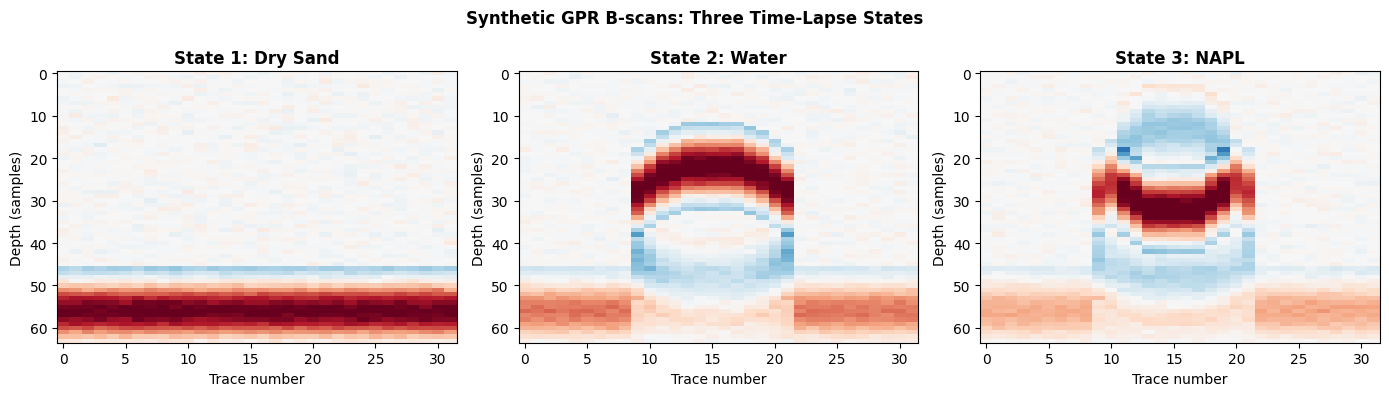

All observed data saved to Drive.


In [5]:
np.random.seed(42)
N_TRACES    = 32
NOISE_LEVEL = 0.10

obs_dry,   tc_dry   = forward_model(eps_dry,   sig_dry,
                                     n_traces=N_TRACES, noise_level=NOISE_LEVEL)
obs_water, tc_water = forward_model(eps_water, sig_water,
                                     n_traces=N_TRACES, noise_level=NOISE_LEVEL)
obs_napl,  tc_napl  = forward_model(eps_napl,  sig_napl,
                                     n_traces=N_TRACES, noise_level=NOISE_LEVEL)

print(f"Dry   data: shape={obs_dry.shape},   range={obs_dry.min():.4f} to {obs_dry.max():.4f}")
print(f"Water data: shape={obs_water.shape}, range={obs_water.min():.4f} to {obs_water.max():.4f}")
print(f"NAPL  data: shape={obs_napl.shape},  range={obs_napl.min():.4f} to {obs_napl.max():.4f}")

# Quick B-scan preview
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['State 1: Dry Sand', 'State 2: Water', 'State 3: NAPL']
for ax, data, title in zip(axes, [obs_dry, obs_water, obs_napl], titles):
    vmax = np.percentile(np.abs(data), 98)
    ax.imshow(data.T, cmap='RdBu', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Trace number')
    ax.set_ylabel('Depth (samples)')
plt.suptitle('Synthetic GPR B-scans: Three Time-Lapse States',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Save to Drive
np.save('obs_dry.npy',   obs_dry);   np.save('tc_dry.npy',   tc_dry)
np.save('obs_water.npy', obs_water); np.save('tc_water.npy', tc_water)
np.save('obs_napl.npy',  obs_napl);  np.save('tc_napl.npy',  tc_napl)
print("All observed data saved to Drive.")

In [6]:
# ---- Shared inversion parameters ----
eps_init         = np.full((H, W), 4.0,   dtype=np.float32)
sig_init         = np.full((H, W), 0.001, dtype=np.float32)
eps_init[56:, :] = 8.0
sig_init[56:, :] = 0.01

N_ITER   = 400
LR_EPS   = 0.05
LR_SIG   = 0.0001
BLEND    = 0.08

def run_inversion(obs_data, trace_cols, state_name):
    print(f"\nRunning inversion: {state_name}...")
    eps = eps_init.copy()
    sig = sig_init.copy()
    for it in range(N_ITER):
        grad_e, grad_s, misfit = compute_gradient(
            eps, sig, obs_data, trace_cols)
        eps = np.clip(eps - LR_EPS * grad_e, EPS_MIN, EPS_MAX)
        sig = np.clip(sig - LR_SIG * grad_s, SIG_MIN, SIG_MAX)
        if it % 5 == 0:
            eps_den, sig_den = diffusion_project_gentle(eps, sig, t_start=50)
            eps = np.clip((1-BLEND)*eps + BLEND*eps_den, EPS_MIN, EPS_MAX)
            sig = np.clip((1-BLEND)*sig + BLEND*sig_den, SIG_MIN, SIG_MAX)
        if (it + 1) % 100 == 0:
            print(f"  iter {it+1}/{N_ITER}, misfit={misfit:.4f}")
    return eps.copy(), sig.copy()

# Run all three states
eps_rec_dry,   sig_rec_dry   = run_inversion(obs_dry,   tc_dry,   'State 1: Dry Sand')
eps_rec_water, sig_rec_water = run_inversion(obs_water, tc_water, 'State 2: Water')
eps_rec_napl,  sig_rec_napl  = run_inversion(obs_napl,  tc_napl,  'State 3: NAPL')

# Compute metrics for all three
metrics_tl = {}
for name, eps_r, sig_r, eps_t, sig_t in [
    ('Dry',   eps_rec_dry,   sig_rec_dry,   eps_dry,   sig_dry),
    ('Water', eps_rec_water, sig_rec_water, eps_water, sig_water),
    ('NAPL',  eps_rec_napl,  sig_rec_napl,  eps_napl,  sig_napl)]:
    re, se = compute_metrics(eps_r, eps_t)
    rs, ss = compute_metrics(sig_r, sig_t)
    metrics_tl[name] = {'eps_rmse': re, 'eps_ssim': se,
                        'sig_rmse': rs, 'sig_ssim': ss}
    print(f"{name}: eps_r RMSE={re:.4f} SSIM={se:.4f} | "
          f"sigma RMSE={rs:.6f} SSIM={ss:.4f}")

# Save to Drive
np.save('eps_rec_dry.npy',   eps_rec_dry)
np.save('sig_rec_dry.npy',   sig_rec_dry)
np.save('eps_rec_water.npy', eps_rec_water)
np.save('sig_rec_water.npy', sig_rec_water)
np.save('eps_rec_napl.npy',  eps_rec_napl)
np.save('sig_rec_napl.npy',  sig_rec_napl)
np.save('metrics_timelapse.npy', metrics_tl, allow_pickle=True)
print("\nAll time-lapse inversion results saved to Drive.")


Running inversion: State 1: Dry Sand...
  iter 100/400, misfit=0.0275
  iter 200/400, misfit=0.0319
  iter 300/400, misfit=0.0404
  iter 400/400, misfit=0.0508

Running inversion: State 2: Water...
  iter 100/400, misfit=1.5052
  iter 200/400, misfit=1.3322
  iter 300/400, misfit=1.2759
  iter 400/400, misfit=1.2507

Running inversion: State 3: NAPL...
  iter 100/400, misfit=4.8645
  iter 200/400, misfit=6.2994
  iter 300/400, misfit=6.8811
  iter 400/400, misfit=7.1350
Dry: eps_r RMSE=0.1116 SSIM=0.9202 | sigma RMSE=0.000388 SSIM=0.7835
Water: eps_r RMSE=5.8154 SSIM=0.7823 | sigma RMSE=0.009777 SSIM=0.6973
NAPL: eps_r RMSE=5.7016 SSIM=0.7016 | sigma RMSE=0.012703 SSIM=0.5662

All time-lapse inversion results saved to Drive.


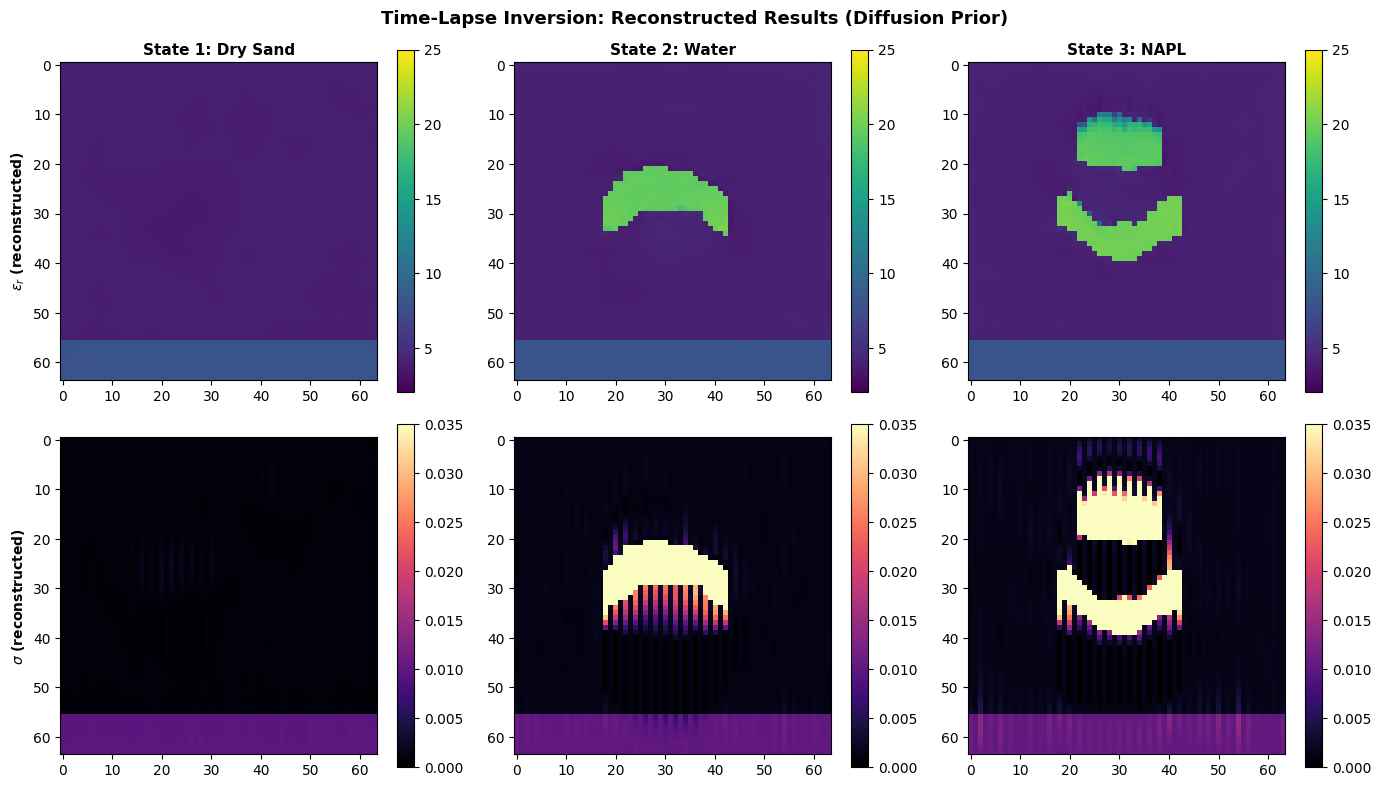

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
states     = ['State 1: Dry Sand', 'State 2: Water', 'State 3: NAPL']
eps_recs   = [eps_rec_dry, eps_rec_water, eps_rec_napl]
sig_recs   = [sig_rec_dry, sig_rec_water, sig_rec_napl]
eps_truths = [eps_dry, eps_water, eps_napl]
sig_truths = [sig_dry, sig_water, sig_napl]

for j in range(3):
    im0 = axes[0, j].imshow(eps_recs[j], cmap='viridis', vmin=2, vmax=25)
    axes[0, j].set_title(states[j], fontsize=11, fontweight='bold')
    if j == 0:
        axes[0, j].set_ylabel(r'$\varepsilon_r$ (reconstructed)',
                               fontsize=10, fontweight='bold')
    plt.colorbar(im0, ax=axes[0, j])

    im1 = axes[1, j].imshow(sig_recs[j], cmap='magma', vmin=0, vmax=0.035)
    if j == 0:
        axes[1, j].set_ylabel(r'$\sigma$ (reconstructed)',
                               fontsize=10, fontweight='bold')
    plt.colorbar(im1, ax=axes[1, j])

plt.suptitle('Time-Lapse Inversion: Reconstructed Results (Diffusion Prior)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
print("Rerunning State 3 (NAPL) with corrected parameters...")
eps = eps_init.copy()
sig = sig_init.copy()

LR_SIG_NAPL = 0.00005  # halved -- prevents sigma divergence on complex case
N_ITER_NAPL = 250

for it in range(N_ITER_NAPL):
    grad_e, grad_s, misfit = compute_gradient(
        eps, sig, obs_napl, tc_napl)
    eps = np.clip(eps - LR_EPS   * grad_e, EPS_MIN, EPS_MAX)
    sig = np.clip(sig - LR_SIG_NAPL * grad_s, SIG_MIN, SIG_MAX)
    if it % 5 == 0:
        eps_den, sig_den = diffusion_project_gentle(eps, sig, t_start=50)
        eps = np.clip((1-BLEND)*eps + BLEND*eps_den, EPS_MIN, EPS_MAX)
        sig = np.clip((1-BLEND)*sig + BLEND*sig_den, SIG_MIN, SIG_MAX)
    if (it + 1) % 50 == 0:
        print(f"  iter {it+1}/{N_ITER_NAPL}, misfit={misfit:.4f}")

eps_rec_napl = eps.copy()
sig_rec_napl = sig.copy()

re, se = compute_metrics(eps_rec_napl, eps_napl)
rs, ss = compute_metrics(sig_rec_napl, sig_napl)
print(f"\nNAPL corrected: eps_r RMSE={re:.4f} SSIM={se:.4f} | "
      f"sigma RMSE={rs:.6f} SSIM={ss:.4f}")

np.save('eps_rec_napl.npy', eps_rec_napl)
np.save('sig_rec_napl.npy', sig_rec_napl)
print("Corrected NAPL results saved to Drive.")

Rerunning State 3 (NAPL) with corrected parameters...
  iter 50/250, misfit=6.2321
  iter 100/250, misfit=4.8828
  iter 150/250, misfit=4.2936
  iter 200/250, misfit=4.1013
  iter 250/250, misfit=4.0615

NAPL corrected: eps_r RMSE=5.0663 SSIM=0.7669 | sigma RMSE=0.008646 SSIM=0.5963
Corrected NAPL results saved to Drive.


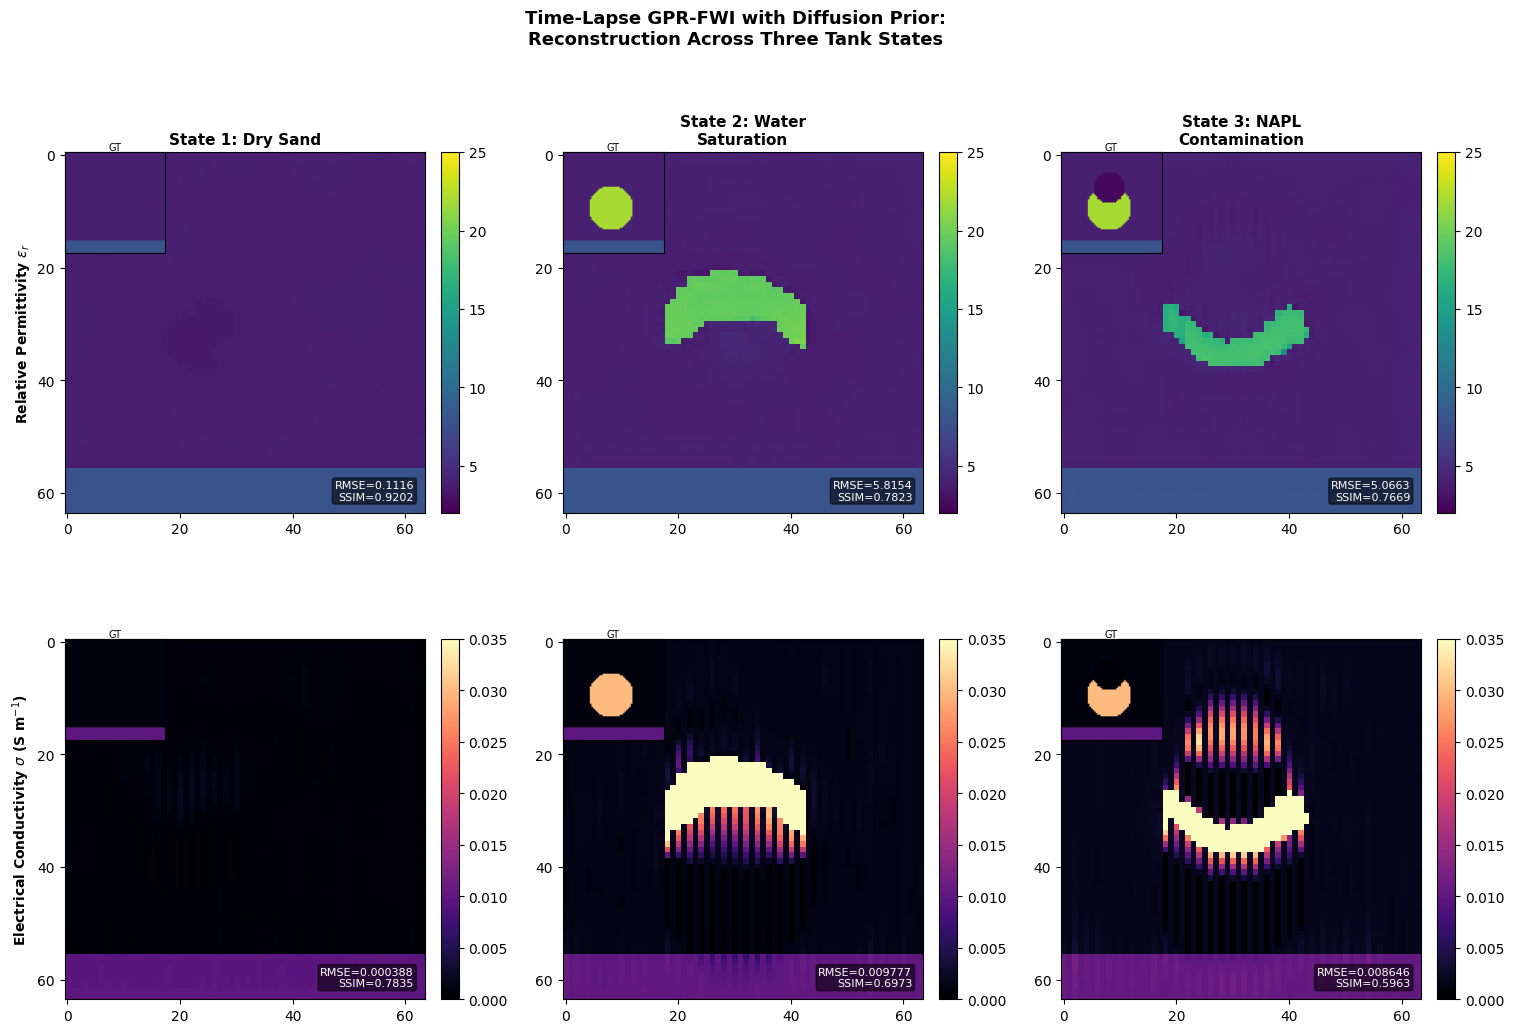

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 6 saved at 300 dpi.


In [9]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 11))
gs  = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.25)

states     = ['State 1: Dry Sand', 'State 2: Water\nSaturation',
               'State 3: NAPL\nContamination']
eps_truths = [eps_dry,      eps_water,      eps_napl]
sig_truths = [sig_dry,      sig_water,      sig_napl]
eps_recs   = [eps_rec_dry,  eps_rec_water,  eps_rec_napl]
sig_recs   = [sig_rec_dry,  sig_rec_water,  sig_rec_napl]

eps_metrics = [
    f"RMSE={metrics_tl['Dry']['eps_rmse']:.4f}\nSSIM={metrics_tl['Dry']['eps_ssim']:.4f}",
    f"RMSE={metrics_tl['Water']['eps_rmse']:.4f}\nSSIM={metrics_tl['Water']['eps_ssim']:.4f}",
    f"RMSE=5.0663\nSSIM=0.7669",
]
sig_metrics = [
    f"RMSE={metrics_tl['Dry']['sig_rmse']:.6f}\nSSIM={metrics_tl['Dry']['sig_ssim']:.4f}",
    f"RMSE={metrics_tl['Water']['sig_rmse']:.6f}\nSSIM={metrics_tl['Water']['sig_ssim']:.4f}",
    f"RMSE=0.008646\nSSIM=0.5963",
]

for j in range(3):
    ax = fig.add_subplot(gs[0, j])

    # Ground truth as inset (top-left corner, small)
    inset = ax.inset_axes([0.0, 0.72, 0.28, 0.28])
    inset.imshow(eps_truths[j], cmap='viridis', vmin=2, vmax=25)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_title('GT', fontsize=7, pad=1)

    # Main: reconstructed
    im = ax.imshow(eps_recs[j], cmap='viridis', vmin=2, vmax=25)
    ax.set_title(states[j], fontsize=11, fontweight='bold')
    ax.set_xticks([0, 20, 40, 60])
    ax.set_yticks([0, 20, 40, 60])
    if j == 0:
        ax.set_ylabel(r'Relative Permittivity $\varepsilon_r$',
                      fontsize=10, fontweight='bold')
    ax.text(0.97, 0.03, eps_metrics[j], transform=ax.transAxes,
            fontsize=8, ha='right', va='bottom', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.55))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for j in range(3):
    ax = fig.add_subplot(gs[1, j])

    inset = ax.inset_axes([0.0, 0.72, 0.28, 0.28])
    inset.imshow(sig_truths[j], cmap='magma', vmin=0, vmax=0.035)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_title('GT', fontsize=7, pad=1)

    im = ax.imshow(sig_recs[j], cmap='magma', vmin=0, vmax=0.035)
    ax.set_xticks([0, 20, 40, 60])
    ax.set_yticks([0, 20, 40, 60])
    if j == 0:
        ax.set_ylabel(r'Electrical Conductivity $\sigma$ (S m$^{-1}$)',
                      fontsize=10, fontweight='bold')
    ax.text(0.97, 0.03, sig_metrics[j], transform=ax.transAxes,
            fontsize=8, ha='right', va='bottom', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.55))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Time-Lapse GPR-FWI with Diffusion Prior:\n'
             'Reconstruction Across Three Tank States',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig('figure6_timelapse_final.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('figure6_timelapse_final.png')
print("Figure 6 saved at 300 dpi.")

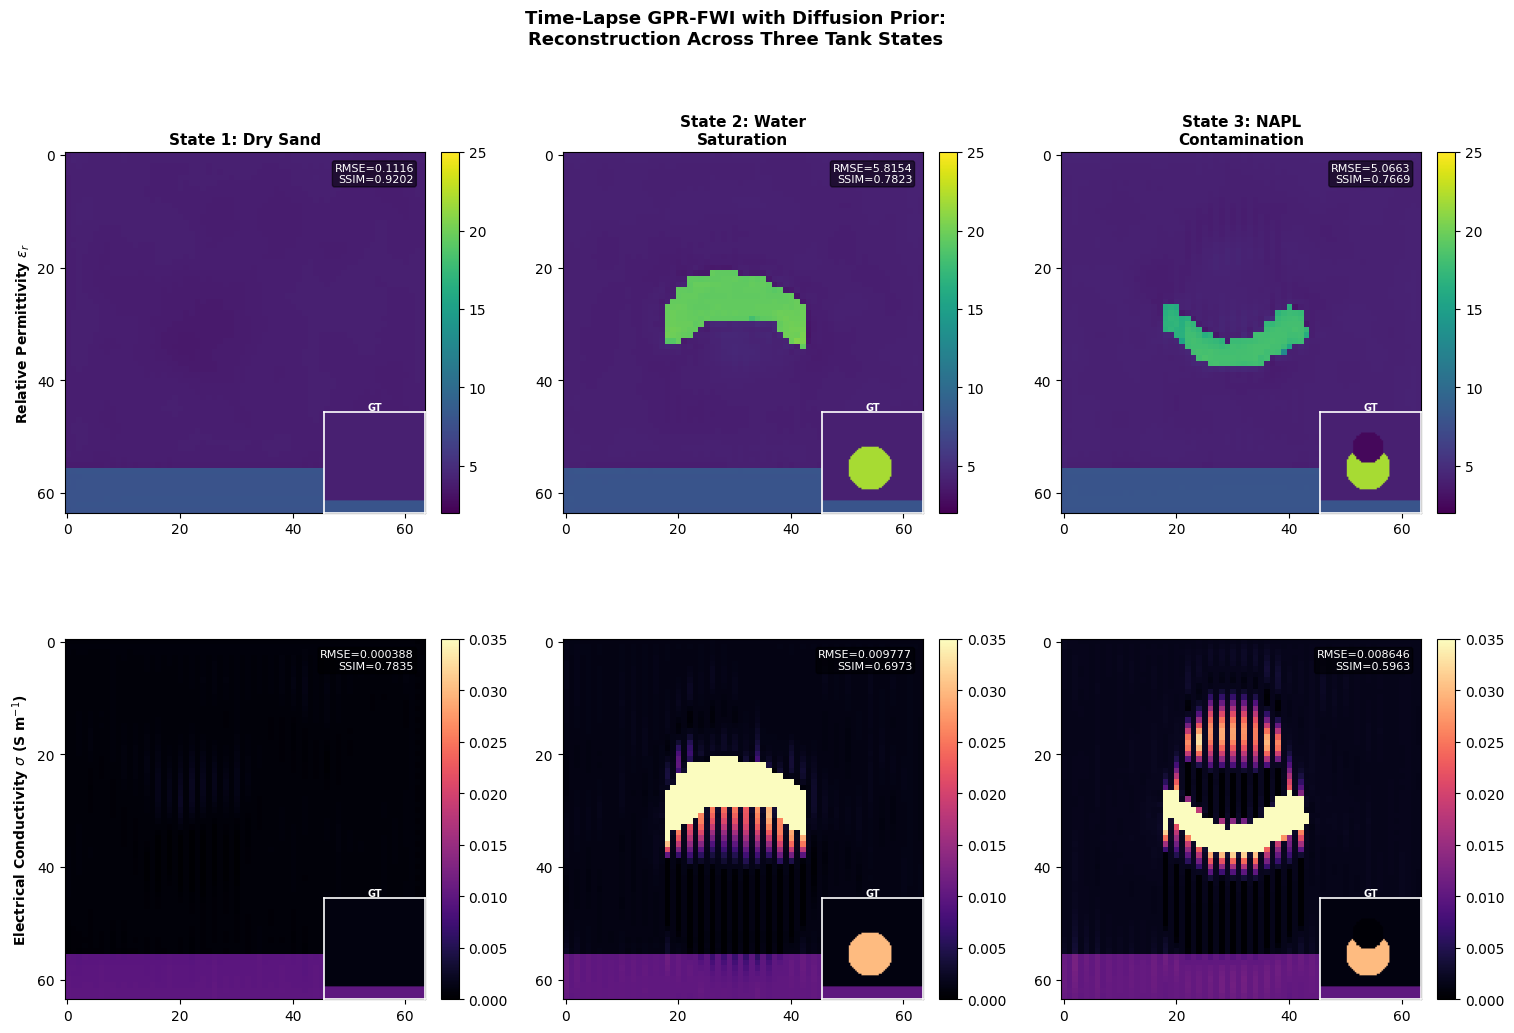

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 6 saved at 300 dpi.


In [10]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 11))
gs  = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.25)

states     = ['State 1: Dry Sand', 'State 2: Water\nSaturation',
               'State 3: NAPL\nContamination']
eps_truths = [eps_dry,     eps_water,     eps_napl]
sig_truths = [sig_dry,     sig_water,     sig_napl]
eps_recs   = [eps_rec_dry, eps_rec_water, eps_rec_napl]
sig_recs   = [sig_rec_dry, sig_rec_water, sig_rec_napl]

eps_metrics = [
    f"RMSE=0.1116\nSSIM=0.9202",
    f"RMSE=5.8154\nSSIM=0.7823",
    f"RMSE=5.0663\nSSIM=0.7669",
]
sig_metrics = [
    f"RMSE=0.000388\nSSIM=0.7835",
    f"RMSE=0.009777\nSSIM=0.6973",
    f"RMSE=0.008646\nSSIM=0.5963",
]

# eps_r row
for j in range(3):
    ax = fig.add_subplot(gs[0, j])
    im = ax.imshow(eps_recs[j], cmap='viridis', vmin=2, vmax=25)
    ax.set_title(states[j], fontsize=11, fontweight='bold')
    ax.set_xticks([0, 20, 40, 60])
    ax.set_yticks([0, 20, 40, 60])
    if j == 0:
        ax.set_ylabel(r'Relative Permittivity $\varepsilon_r$',
                      fontsize=10, fontweight='bold')
    # Ground truth inset -- bottom right, shared colorscale
    inset = ax.inset_axes([0.72, 0.0, 0.28, 0.28])
    inset.imshow(eps_truths[j], cmap='viridis', vmin=2, vmax=25)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_title('GT', fontsize=7, pad=1, color='white',
                    fontweight='bold')
    for spine in inset.spines.values():
        spine.set_edgecolor('white')
        spine.set_linewidth(1.2)
    # Metrics -- top right
    ax.text(0.97, 0.97, eps_metrics[j], transform=ax.transAxes,
            fontsize=8, ha='right', va='top', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.55))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# sigma row
for j in range(3):
    ax = fig.add_subplot(gs[1, j])
    im = ax.imshow(sig_recs[j], cmap='magma', vmin=0, vmax=0.035)
    ax.set_xticks([0, 20, 40, 60])
    ax.set_yticks([0, 20, 40, 60])
    if j == 0:
        ax.set_ylabel(r'Electrical Conductivity $\sigma$ (S m$^{-1}$)',
                      fontsize=10, fontweight='bold')
    # Ground truth inset -- bottom right, shared colorscale
    inset = ax.inset_axes([0.72, 0.0, 0.28, 0.28])
    inset.imshow(sig_truths[j], cmap='magma', vmin=0, vmax=0.035)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_title('GT', fontsize=7, pad=1, color='white',
                    fontweight='bold')
    for spine in inset.spines.values():
        spine.set_edgecolor('white')
        spine.set_linewidth(1.2)
    # Metrics -- top right
    ax.text(0.97, 0.97, sig_metrics[j], transform=ax.transAxes,
            fontsize=8, ha='right', va='top', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.55))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Time-Lapse GPR-FWI with Diffusion Prior:\n'
             'Reconstruction Across Three Tank States',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig('figure6_timelapse_final.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('figure6_timelapse_final.png')
print("Figure 6 saved at 300 dpi.")